*Hi all, 
This is a beginners' work. Feel Free to upvote it if you like. 
Also improvements and changes would be highly appreciated.
Thank you!!!*


**Dashboard to search for restaurant According To Their Name,location,rating,cost for two**
Analysis of Restaurant based on :

    1. Their Rating 
    2. Online Delivery
    3. Their Type whether Bar,Dinner, buffet etc
    4. Table Booking facility
    5. Single Cuisine type or Multi Cuisine Type
    6. Most Liked Dishes
    7. Largest Number of Food Chains in Bangalore
    8. Average Price for Two people 

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('dark_background')

In [2]:
data=pd.read_csv('C:/Visual Studio Code/Zomato Analysis/data/raw/zomato.csv')

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

In [4]:
data.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


# DATA CLEANING

In [5]:
#Removing unnecessary data such as url, address and phone columns from DataFrame

In [6]:
del data['url']
del data['address']
del data['phone']

In [7]:
#Replacing restaurants with their ratings given as New to NAN and dropping them finally 
data['rate'] = data['rate'].replace('NEW',np.nan)
data['rate'] = data['rate'].replace('-',np.nan)
data.dropna(how = 'any', inplace = True)

In [8]:
data['rate'] = data.loc[:,'rate'].replace('[ ]','',regex = True)
data['rate'] = data['rate'].astype(str)
data['rate'] = data['rate'].apply(lambda r: r.replace('/5',''))
data['rate'] = data['rate'].apply(lambda r: float(r))

In [9]:
#Conversion of Cost from String to Integer
data['approx_cost(for two people)'] = data['approx_cost(for two people)'].str.replace(',','')
data['approx_cost(for two people)'] = data['approx_cost(for two people)'].astype(int)

In [10]:
data.head()

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


# Dashboard to search for restaurant According To Their Name,location,rating,cost for two.

In [11]:
from __future__ import print_function
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

In [12]:
location=['Banashankari', 'Basavanagudi', 'Jayanagar', 'Kumaraswamy Layout',
       'Rajarajeshwari Nagar', 'Mysore Road', 'Uttarahalli',
       'South Bangalore', 'Vijay Nagar', 'Bannerghatta Road', 'JP Nagar',
       'BTM', 'Wilson Garden', 'Koramangala 5th Block', 'Shanti Nagar',
       'Richmond Road', 'City Market', 'Bellandur', 'Sarjapur Road',
       'Marathahalli', 'HSR', 'Old Airport Road', 'Indiranagar',
       'Koramangala 1st Block', 'East Bangalore', 'MG Road',
       'Brigade Road', 'Lavelle Road', 'Church Street', 'Ulsoor',
       'Residency Road', 'Shivajinagar', 'Infantry Road',
       'St. Marks Road', 'Cunningham Road', 'Race Course Road', 'Domlur',
       'Koramangala 8th Block', 'Frazer Town', 'Ejipura', 'Vasanth Nagar',
       'Jeevan Bhima Nagar', 'Old Madras Road', 'Commercial Street',
       'Koramangala 6th Block', 'Majestic', 'Langford Town',
       'Koramangala 7th Block', 'Brookefield', 'Whitefield',
       'ITPL Main Road, Whitefield', 'Varthur Main Road, Whitefield',
       'Koramangala 2nd Block', 'Koramangala 3rd Block',
       'Koramangala 4th Block', 'Koramangala', 'Bommanahalli',
       'Hosur Road', 'Seshadripuram', 'Electronic City', 'Banaswadi',
       'North Bangalore', 'RT Nagar', 'Kammanahalli', 'Hennur',
       'HBR Layout', 'Kalyan Nagar', 'Thippasandra', 'CV Raman Nagar',
       'Kaggadasapura', 'Kanakapura Road', 'Nagawara', 'Rammurthy Nagar',
       'Sankey Road', 'Central Bangalore', 'Malleshwaram',
       'Sadashiv Nagar', 'Basaveshwara Nagar', 'Rajajinagar',
       'New BEL Road', 'West Bangalore', 'Yeshwantpur', 'Sanjay Nagar',
       'Sahakara Nagar', 'Jalahalli', 'Yelahanka', 'Magadi Road',
       'KR Puram']
location.sort()
print("Search Restaurants according to their name")
@interact
def show_articles_more_than(Restaurant_Name=''):
    return data[data['name'].str.contains(Restaurant_Name)]


Search Restaurants according to their name


interactive(children=(Text(value='', description='Restaurant_Name'), Output()), _dom_classes=('widget-interact…

*Search Restaurant According To your requirements*
* Location - Chose Any location where you want to go
* Type - Chose the type of Restaurant where you want to go whether cafe,pub etc
* Min_Rating - Select the minimum rating which you want, search results will have atleast rating searched or more than that
* Max_Cost_For_two - Select the max cost for two people and it will show restaurants having that much cost or below it.

In [13]:
@interact
def show_Restaurants_according_to_search(Location=location,
                                         Restaurant_Type=['Buffet', 
                                             'Cafes',
                                             'Delivery',
                                             'Desserts',
                                             'Dine-out',
                                             'Drinks & nightlife',
                                             'Pubs and bars'],
                            Min_Rating=(0,5,0.1),
                            Max_Cost_For_Two_People=(100,5000,50)):
    print("")
    return data[ (data['rate'] > Min_Rating) 
                &(data['listed_in(type)'] == Restaurant_Type) 
                &(data['location'] == Location) 
                & (data['approx_cost(for two people)'] < Max_Cost_For_Two_People)]

interactive(children=(Dropdown(description='Location', options=('BTM', 'Banashankari', 'Banaswadi', 'Bannergha…

# Analysis of Restaurants based on their Online Delivery

In [14]:
print("No. of restaurants with online delivery:")
(data.online_order == 'Yes').sum()

No. of restaurants with online delivery:


np.int64(16387)

In [15]:
print("No. of restaurants which does not deliver online:")
(data.online_order == 'No').sum()

No. of restaurants which does not deliver online:


np.int64(6872)

In [16]:
data.name.count()

np.int64(23259)

Text(0.5, 1.0, 'Restaurants delivering online or Not')

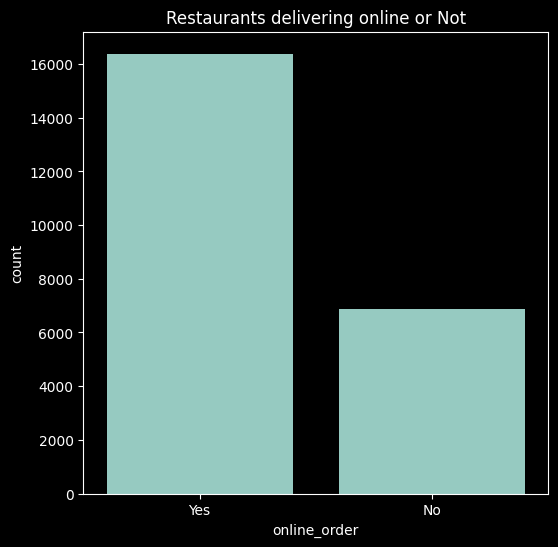

In [17]:
sns.countplot(x=data['online_order'])
fig = plt.gcf()
fig.set_size_inches(6,6)
plt.title('Restaurants delivering online or Not')

Text(0.5, 1.0, 'Type of Restaurants delivering online or Not')

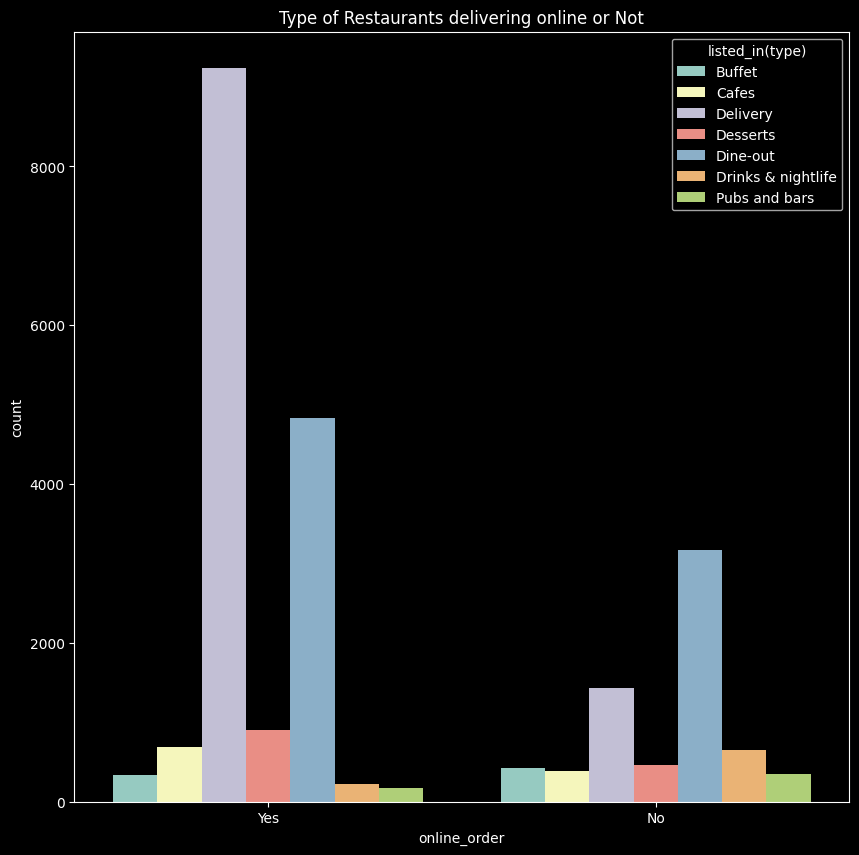

In [18]:
sns.countplot(x=data['online_order'], hue = data['listed_in(type)'])
fig = plt.gcf()
fig.set_size_inches(10,10)
plt.title('Type of Restaurants delivering online or Not')

# Analysis of Restaurants based on their Table booking facility

In [19]:
print("No. of restaurants with table booking facility:")
(data.book_table == 'Yes').sum()

No. of restaurants with table booking facility:


np.int64(6061)

In [20]:
print("No. of restaurants with table booking facility:")
(data.book_table == 'No').sum()

No. of restaurants with table booking facility:


np.int64(17198)

Text(0.5, 1.0, 'Restaurants providing Table booking facility:')

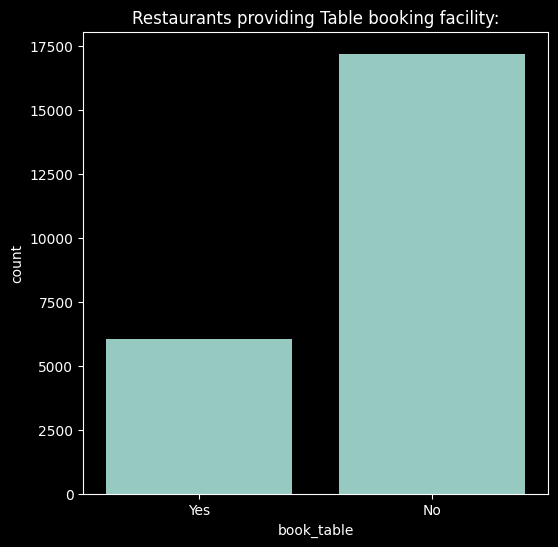

In [21]:
sns.countplot(x=data['book_table'])
fig = plt.gcf()
fig.set_size_inches(6,6)
plt.title('Restaurants providing Table booking facility:')

Text(0.5, 1.0, 'Type Of Restaurants providing Table booking facility:')

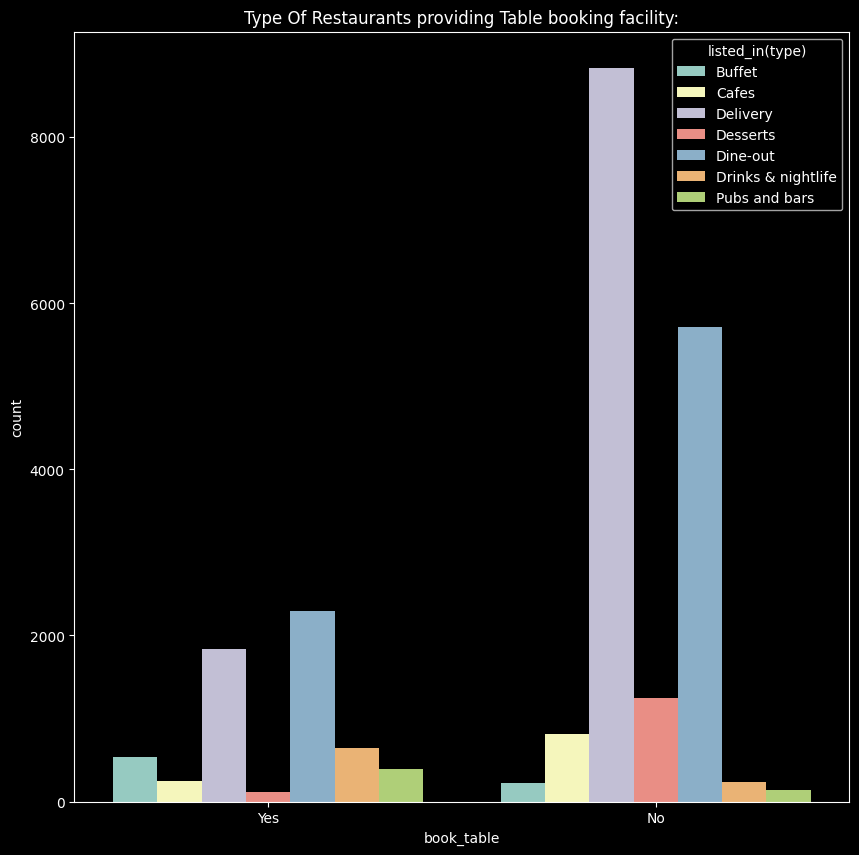

In [22]:
sns.countplot(x=data['book_table'],hue = data['listed_in(type)'])
fig = plt.gcf()
fig.set_size_inches(10,10)
plt.title('Type Of Restaurants providing Table booking facility:')

# Analysis of Restaurants based on their Ratings

In [23]:
print("All unique restaurants ratings:")
data.rate.unique()

All unique restaurants ratings:


array([4.1, 3.8, 3.7, 4.6, 4. , 4.2, 3.9, 3. , 3.6, 2.8, 4.4, 3.1, 4.3,
       2.6, 3.3, 3.5, 3.2, 4.5, 2.5, 2.9, 3.4, 2.7, 4.7, 2.4, 2.2, 2.3,
       4.8, 4.9, 2.1, 2. , 1.8])

In [24]:
print("no. of restaurants between 1.5 and 2 rating:")
((data.rate>=1.5) & (data.rate<2)).sum()

no. of restaurants between 1.5 and 2 rating:


np.int64(5)

In [25]:
print("no. of restaurants between 2.5 and 3 rating:")
((data.rate>=2.5) & (data.rate<3)).sum()

no. of restaurants between 2.5 and 3 rating:


np.int64(1019)

In [26]:
print("no. of restaurants between 2 and 2.5 rating:")
((data.rate>=2) & (data.rate<2.5)).sum()

no. of restaurants between 2 and 2.5 rating:


np.int64(160)

In [27]:
print("no. of restaurants between 3.0 and 3.5 rating:")
((data.rate>=3.0) & (data.rate<3.5)).sum()

no. of restaurants between 3.0 and 3.5 rating:


np.int64(1418)

In [28]:
print("no. of restaurants between 3.5 and 4 rating:")
((data.rate>=3.5) & (data.rate<4)).sum()

no. of restaurants between 3.5 and 4 rating:


np.int64(8740)

In [29]:
print("no. of restaurants between 4 and 4.5 rating:")
((data.rate>=4) & (data.rate<4.5)).sum()

no. of restaurants between 4 and 4.5 rating:


np.int64(10681)

In [30]:
print("no. of restaurants between 4.5 and 5 rating:")
((data.rate>=4.5) & (data.rate<5)).sum()

no. of restaurants between 4.5 and 5 rating:


np.int64(1236)

ValueError: Invalid string grayscale value '2'. Value must be within 0-1 range

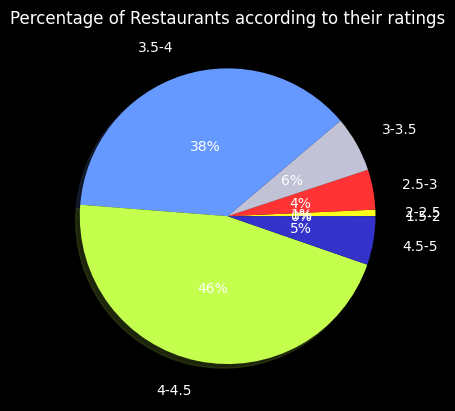

In [31]:
slices=[((data.rate>=1.5) & (data.rate<2)).sum(),
        ((data.rate>=2) & (data.rate<2.5)).sum(),
        ((data.rate>=2.5) & (data.rate<3)).sum(),
        ((data.rate>=3.0) & (data.rate<3.5)).sum(),
        ((data.rate>=3.5) & (data.rate<4)).sum(),
        ((data.rate>=4) & (data.rate<4.5)).sum(),
        ((data.rate>=4.5) & (data.rate<5)).sum()
       ]
labels=['1.5-2','2-2.5','2.5-3','3-3.5','3.5-4','4-4.5','4.5-5']
colors = ['#3333cc','#ffff1a','#ff3333','#c2c2d6','#6699ff','#c4ff4d']
plt.pie(slices,colors=colors, labels=labels, autopct='%1.0f%%', pctdistance=.5, labeldistance=1.2,shadow=True)
fig = plt.gcf()
plt.title("Percentage of Restaurants according to their ratings", bbox={'facecolor':'2', 'pad':5})

fig.set_size_inches(10,10)
plt.show()

* Analysis of Restaurants based on their online order and how rating is related to it

In [ ]:
plt.figure(figsize=(20,10))
ax = sns.countplot(x='rate',hue='book_table',data=data)
plt.title('Rating of Restaurants vs Table Booking')
plt.show()

* Analysis of Restaurants based on their online order and how rating is related to it

In [ ]:
plt.figure(figsize=(20,10))
ax = sns.countplot(x='rate',hue='online_order',data=data)
plt.title('Rating of Restaurants vs Online Delivery')
plt.show()

It is Clearly visible that table Booking doesnot affect much to a restaurant ratings in comparison to online delivery. People tend to prefer order online since they can get various offers from it. That's why online delivery is more important for restaurants in bangalore to flourish

# Analysis of Restaurants based on their Location

In [ ]:
print("All unique locations of restaurants in Bangalore")
data.location.unique()

In [ ]:
print("Count of restaurants at unique locations")
locationCount=data['location'].value_counts().sort_values(ascending=True)
locationCount

In [ ]:
#lets check max count
print("Maximum number of Resaturants Present at:")
count_max=max(locationCount)
for x,y in locationCount.items():
    if(y==count_max):
        print(x)

In [ ]:
#lets check min count
print("minimum number of Restaurants present at:")
min_count=min(locationCount)
for x,y in locationCount.items():
    if(y==min_count):
        print(x)

In [ ]:
fig=plt.figure(figsize=(20,40))
locationCount.plot(kind="barh",fontsize=20)
plt.ylabel("Location names",fontsize=50,color="red",fontweight='bold')
plt.title("LOCATION VS RESTAURANT COUNT GRAPH",fontsize=40,color="BLACK",fontweight='bold')
for v in range(len(locationCount)):
    #plt.text(x axis location ,y axis location ,text value ,other parameters......)
    plt.text(v+locationCount[v],v,locationCount[v],fontsize=10,color="BLACK",fontweight='bold')

# Analysis of Restaurants based on their Dining Type

In [ ]:
print("All different dining type restaurants")
data['listed_in(type)'].unique()

In [ ]:
print("Count of All different dining type restaurants")
restaurantTypeCount=data['listed_in(type)'].value_counts().sort_values(ascending=True)
restaurantTypeCount

In [ ]:
slices=[restaurantTypeCount[0],
        restaurantTypeCount[1],
        restaurantTypeCount[2],
        restaurantTypeCount[3],
        restaurantTypeCount[4],
        restaurantTypeCount[5],
        restaurantTypeCount[6]]
labels=['Pubs and bars','Buffet','Drinks & nightlife','Cafes','Desserts','Dine-out','Delivery ']
colors = ['#3333cc','#ffff1a','#ff3333','#c2c2d6','#6699ff','#c4ff4d','#339933']
plt.pie(slices,colors=colors, labels=labels, autopct='%1.0f%%', pctdistance=.5, labeldistance=1.2,shadow=True)
fig = plt.gcf()
plt.title("Percentage of Restaurants according to their Type", bbox={'facecolor':'2', 'pad':5})

fig.set_size_inches(12,12)
plt.show()

# Analysis of Restaurants based on their Subcity Type

In [ ]:
CityCount=data['listed_in(city)'].value_counts().sort_values(ascending=True)
CityCount

In [ ]:
fig=plt.figure(figsize=(20,20))
CityCount.plot(kind="barh",fontsize=20)
plt.ylabel("Location names",fontsize=50,color="red",fontweight='bold')
plt.title("CITY VS RESTAURANT COUNT GRAPH",fontsize=40,color="BLACK",fontweight='bold')
for v in range(len(CityCount)):
    #plt.text(x axis location ,y axis location ,text value ,other parameters......)
    plt.text(v+CityCount[v],v,CityCount[v],fontsize=10,color="BLACK",fontweight='bold')

In [ ]:
CostCount=data['approx_cost(for two people)'].value_counts().sort_values(ascending=True)
fig=plt.figure(figsize=(25,25))
CostCount.plot(kind="barh",fontsize=20)
plt.ylabel("Cost For Two People",fontsize=50,color="red",fontweight='bold')
plt.title("COST FOR 2 PEOPLE VS RESTAURANT  GRAPH",fontsize=40,color="BLACK",fontweight='bold')


In [ ]:
data.votes.describe()

In [ ]:
data[((data.votes>=300)==True) & ((data.rate>=4)==True)].describe()

# Analysis of Restaurants based on their FoodType

In [ ]:
print("all different cuisines:")
cuisines = set()
for i in data['cuisines']:
    for j in str(i).split(', '):
        cuisines.add(j)
cuisines

### Get All the North Indian Food Serving Restaurants

In [ ]:
NorthIndianFoodRestaurants = data[data['cuisines'].str.contains('North Indian', case=False, regex=True,na=False)]
NorthIndianFoodRestaurants.head()

### Get All the Chinese Food Serving Restaurants

In [ ]:
ChineseFoodRestaurants = data[data['cuisines'].str.contains('Chinese|Momos', case=False, regex=True,na=False)]
ChineseFoodRestaurants.head()

### Get All the South Indian Food Serving Restaurants

In [ ]:
SouthIndianFoodRestaurants = data[data['cuisines'].str.contains('South Indian', case=False, regex=True,na=False)]
SouthIndianFoodRestaurants.head()

### Get All the Italian Food Serving Restaurants

In [ ]:

ItalianFoodRestaurants = data[data['cuisines'].str.contains('Italian|Pizza', case=False, regex=True,na=False)]
ItalianFoodRestaurants.head()

### Get All the Mexican Food Serving Restaurants

In [ ]:
MexicanFoodRestaurants = data[data['cuisines'].str.contains('Mexican', case=False, regex=True,na=False)]
MexicanFoodRestaurants.head()

### Get All the American Food Serving Restaurants

In [ ]:
AmericanFoodRestaurants = data[data['cuisines'].str.contains('American|Burger', case=False, regex=True,na=False)]
AmericanFoodRestaurants.head()

### Get All the Mughlai Food Serving Restaurants

In [ ]:
MughlaiFoodRestaurants = data[data['cuisines'].str.contains('Mughlai', case=False, regex=True,na=False)]
MughlaiFoodRestaurants.head()

In [ ]:
#pie chart showing % of various Food serving Type Restaurants
slices=[MughlaiFoodRestaurants.shape[0],
        ChineseFoodRestaurants.shape[0],
        MexicanFoodRestaurants.shape[0],
        NorthIndianFoodRestaurants.shape[0],
        SouthIndianFoodRestaurants.shape[0],
        ItalianFoodRestaurants.shape[0],
        AmericanFoodRestaurants.shape[0]]
labels=['Mughlai','Chinese','Mexican','North Indian','South Indian','Italian','American']
colors = ['#3333cc','#ffff1a','#ff3333','#c2c2d6','#6699ff','#c4ff4d','#339933']
plt.pie(slices,colors=colors, labels=labels, autopct='%1.0f%%', pctdistance=.5, labeldistance=1.2,shadow=True)
fig = plt.gcf()
plt.title("Percentage of Restaurants according to their Food Type", bbox={'facecolor':'2', 'pad':5})

fig.set_size_inches(12,12)
plt.show()

# Analysis of Restaurants Whether Single Cuisine or Multi Cusine

In [ ]:
SingleTypeofFoodServing = data[data['cuisines'].str.contains(',', case=False, regex=True,na=False)==False]


In [ ]:
MultipleTypeofFoodServing = data[data['cuisines'].str.contains(',', case=False, regex=True,na=False)]


In [ ]:
# Pie chart showing Percentage of Restaurants serving single type vs Multiple type of Foods
labels = ['Single Type of Food Serving', 'Multiple Type of Food Serving', ]
sizes = [SingleTypeofFoodServing.shape[0], MultipleTypeofFoodServing.shape[0]]

explode = (0, 0.1)

colors = ['#99ff99','#66b3ff']
fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=150)

ax1.axis('equal')
plt.title("Percentage of Restaurants serving single type vs Multiple type of Foods", bbox={'facecolor':'2', 'pad':5})
fig1.set_size_inches(10,10)
plt.tight_layout()
plt.show()

#  MOST LIKED DISHES IN BANGALORE

#### Let's store the dishes liked in seperate list and then analyse it. 

In [ ]:
import re
data=data[data['dish_liked'].notnull()]
data.index=range(data.shape[0])
likes=[]
for i in range(data.shape[0]):
    splited_array=re.split(',',data['dish_liked'][i])
    for item in splited_array:
        likes.append(item)




In [ ]:
print("Count of Most liked dishes of Bangalore")
favourite_food = pd.Series(likes).value_counts()
favourite_food.head(20)

In [ ]:
ax = favourite_food.nlargest(n=20, keep='first').plot('bar',figsize=(15,15),title = 'Top 20 Favourite Food counts ')

for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

    

### ANALYSIS OF BIGGEST FOOD CHAINS OF BANGALORE

In [ ]:
branches = data.groupby(['name']).size().to_frame('count').reset_index().sort_values(['count'],ascending=False)
ax = sns.barplot(x='name', y='count', data=branches[:12])
plt.xlabel('')
plt.ylabel('Branches')
plt.title('Food chains and their counts')
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))
    
fig = plt.gcf()
fig.set_size_inches(25,15)

* Onesta has highest number of chains in Bangalore